In [1]:
# import libraries
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("/kaggle/input/datasets/noordeen/insurance-premium-prediction/insurance.csv")

In [3]:
df

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86
...,...,...,...,...,...,...,...
1333,50,male,31.0,3,no,northwest,10600.55
1334,18,female,31.9,0,no,northeast,2205.98
1335,18,female,36.9,0,no,southeast,1629.83
1336,21,female,25.8,0,no,southwest,2007.95


# EDA 

In [4]:
df.shape

(1338, 7)

In [5]:
df.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


In [6]:
df.sample(5)

,age,sex,bmi,children,smoker,region,expenses
1289,44,male,34.3,1,no,southeast,7147.47
50,18,female,35.6,0,no,northeast,2211.13
1078,28,male,31.7,0,yes,southeast,34672.15
410,19,male,17.5,0,no,northwest,1621.34
1066,48,male,37.3,2,no,southeast,8978.19


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [8]:
df.describe()

,age,bmi,children,expenses
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.665471,1.094918,13270.422414
std,14.049960,6.098382,1.205493,12110.011240
min,18.000000,16.000000,0.000000,1121.870000
25%,27.000000,26.300000,0.000000,4740.287500
50%,39.000000,30.400000,1.000000,9382.030000
75%,51.000000,34.700000,2.000000,16639.915000
max,64.000000,53.100000,5.000000,63770.430000


In [9]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64

In [10]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'expenses'], dtype='object')

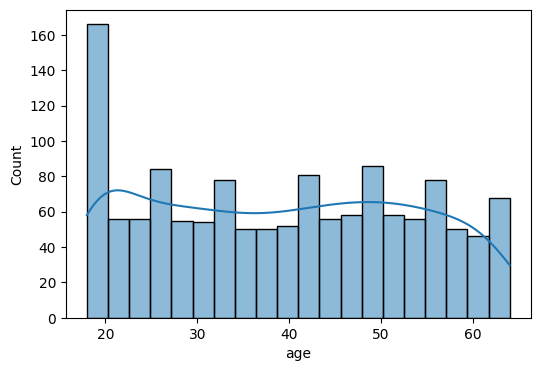

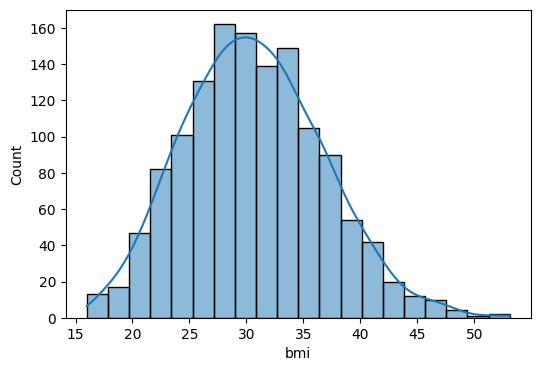

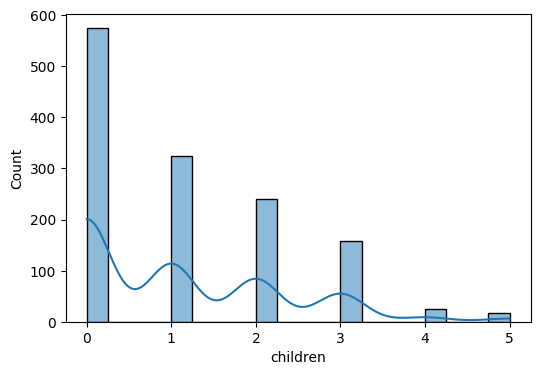

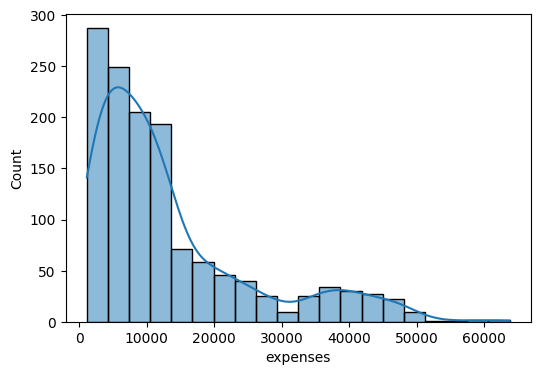

In [11]:
numeric_cols=['age', 'bmi', 'children', 'expenses']
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde=True,bins=20)

<Axes: xlabel='children', ylabel='count'>

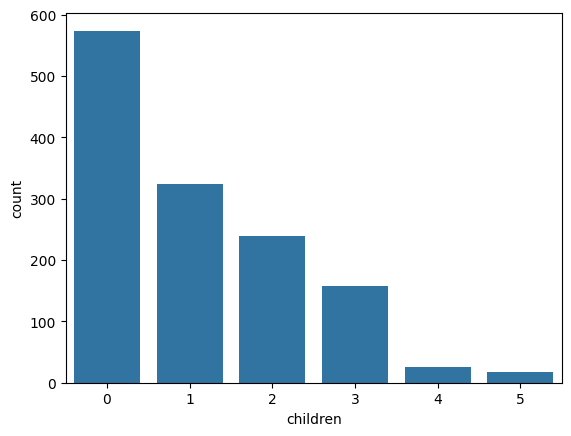

In [12]:
sns.countplot(x=df['children'])

<Axes: xlabel='sex', ylabel='count'>

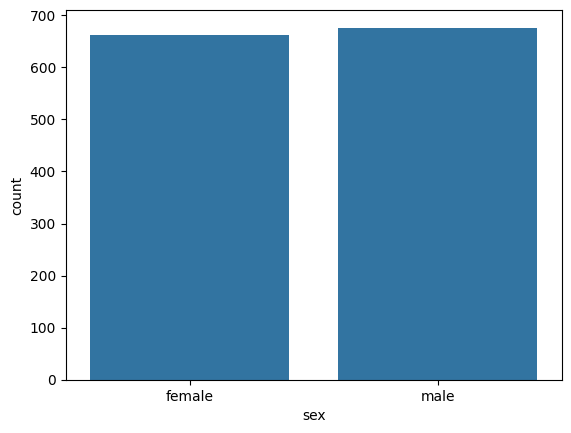

In [13]:
sns.countplot(x=df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

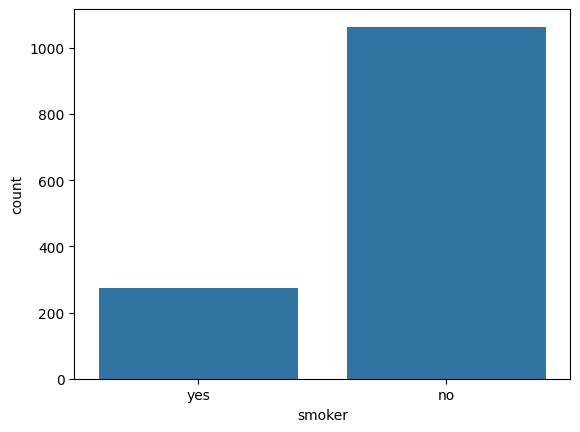

In [14]:
sns.countplot(x=df['smoker'])

<Axes: xlabel='bmi', ylabel='count'>

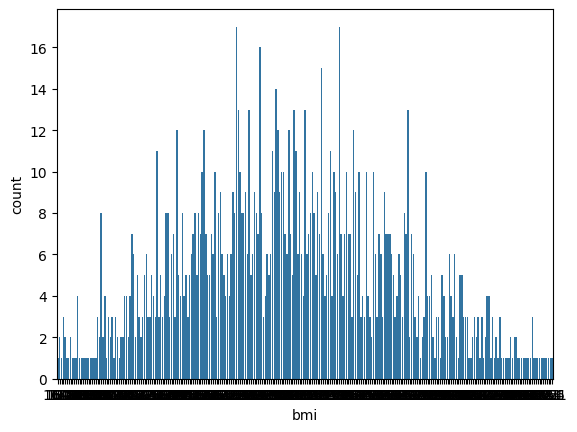

In [15]:
sns.countplot(x=df['bmi'])

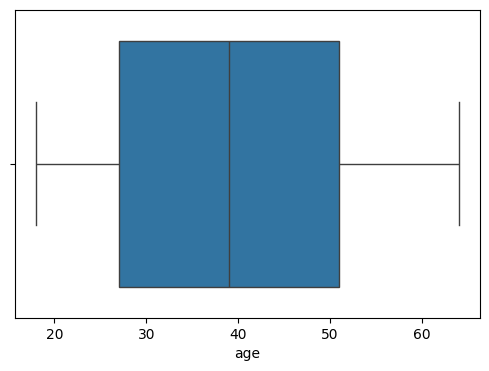

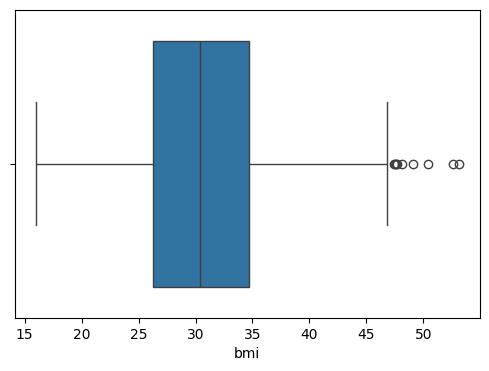

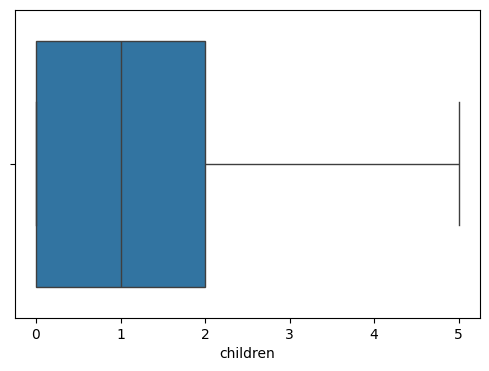

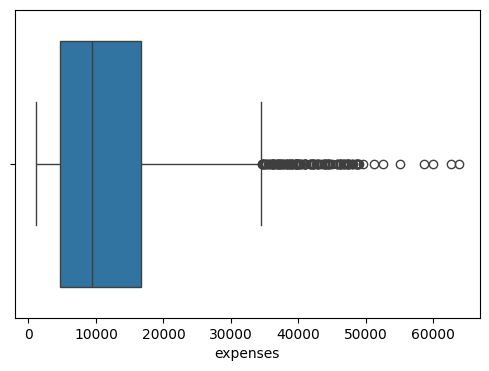

In [16]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    

<Axes: >

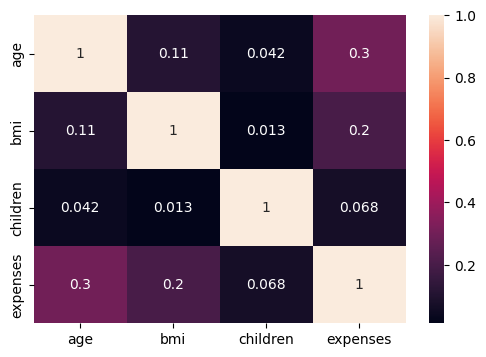

In [17]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True),annot=True)

# Data Cleaning And Preprocessing

In [18]:
df_clean=df.copy()
df_clean.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


In [19]:
df_clean.drop_duplicates(inplace=True)


In [20]:
df.shape

(1338, 7)

In [21]:
df_clean.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64

In [22]:
df_clean.dtypes


age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
expenses    float64
dtype: object

In [23]:
df_clean['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [24]:
df_clean['sex']=df_clean['sex'].map({'male':0,'female':1})

In [25]:
df_clean.head(10)

,age,sex,bmi,children,smoker,region,expenses
0,19,1,27.9,0,yes,southwest,16884.92
1,18,0,33.8,1,no,southeast,1725.55
2,28,0,33.0,3,no,southeast,4449.46
3,33,0,22.7,0,no,northwest,21984.47
4,32,0,28.9,0,no,northwest,3866.86
5,31,1,25.7,0,no,southeast,3756.62
6,46,1,33.4,1,no,southeast,8240.59
7,37,1,27.7,3,no,northwest,7281.51
8,37,0,29.8,2,no,northeast,6406.41
9,60,1,25.8,0,no,northwest,28923.14


In [26]:
df_clean['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [27]:
df_clean['smoker']=df_clean['smoker'].map({'no ':0,'yes':1})

In [28]:
df_clean

,age,sex,bmi,children,smoker,region,expenses
0,19,1,27.9,0,1.0,southwest,16884.92
1,18,0,33.8,1,NaN,southeast,1725.55
2,28,0,33.0,3,NaN,southeast,4449.46
3,33,0,22.7,0,NaN,northwest,21984.47
4,32,0,28.9,0,NaN,northwest,3866.86
...,...,...,...,...,...,...,...
1333,50,0,31.0,3,NaN,northwest,10600.55
1334,18,1,31.9,0,NaN,northeast,2205.98
1335,18,1,36.9,0,NaN,southeast,1629.83
1336,21,1,25.8,0,NaN,southwest,2007.95
